Filas, columnas: (10000, 6)

Columnas y tipos:
Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

Describe (numéricas):
       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        69.445700      6.530600   
std         2.589309        17.343152      1.695863   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.000000   
50%         5.000000        69.000000      7.000000   
75%         7.000000        85.000000      8.000000   
max         9.000000        99.000000      9.000000   

       Sample Question Papers Practiced  Performance Index  
count                      10000.000000       10000.000000  
mean                           4.5

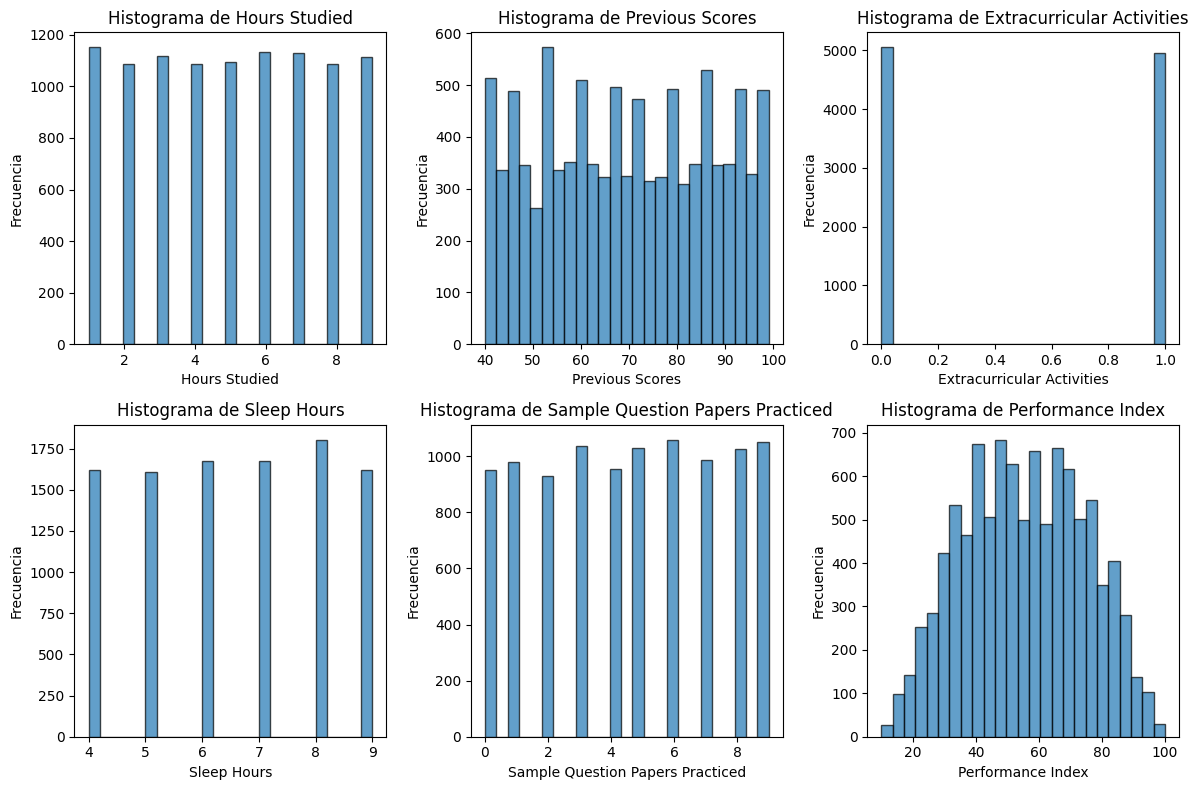

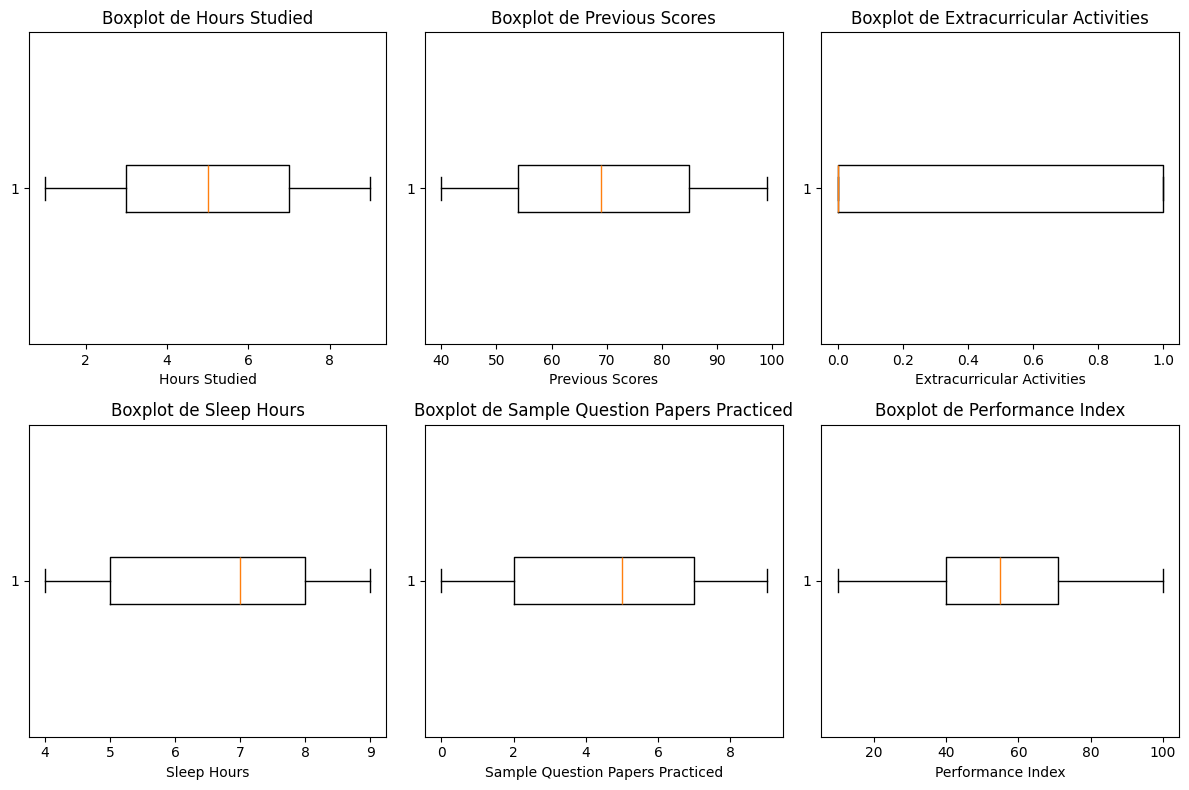

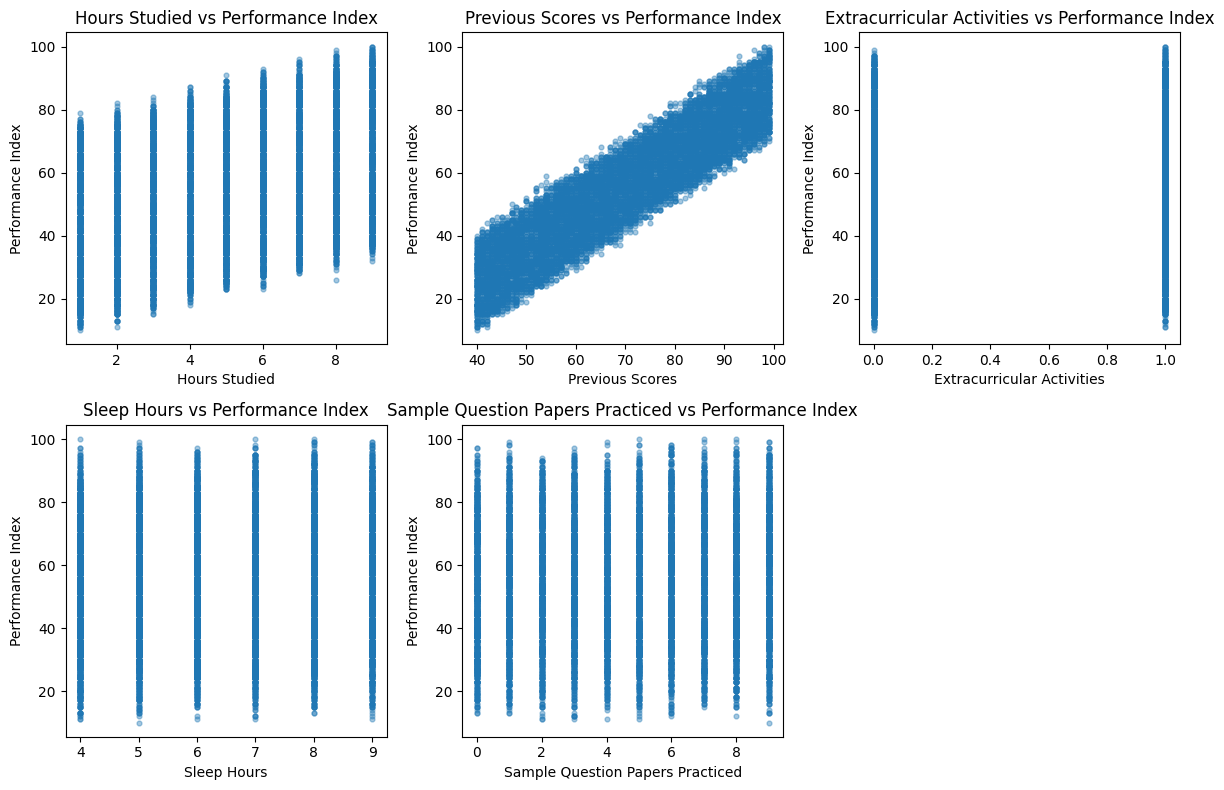


Matriz de correlación numérica:
                                  Hours Studied  Previous Scores  \
Hours Studied                          1.000000        -0.012390   
Previous Scores                       -0.012390         1.000000   
Extracurricular Activities             0.003873         0.008369   
Sleep Hours                            0.001245         0.005944   
Sample Question Papers Practiced       0.017463         0.007888   
Performance Index                      0.373730         0.915189   

                                  Extracurricular Activities  Sleep Hours  \
Hours Studied                                       0.003873     0.001245   
Previous Scores                                     0.008369     0.005944   
Extracurricular Activities                          1.000000    -0.023284   
Sleep Hours                                        -0.023284     1.000000   
Sample Question Papers Practiced                    0.013103     0.003990   
Performance Index           

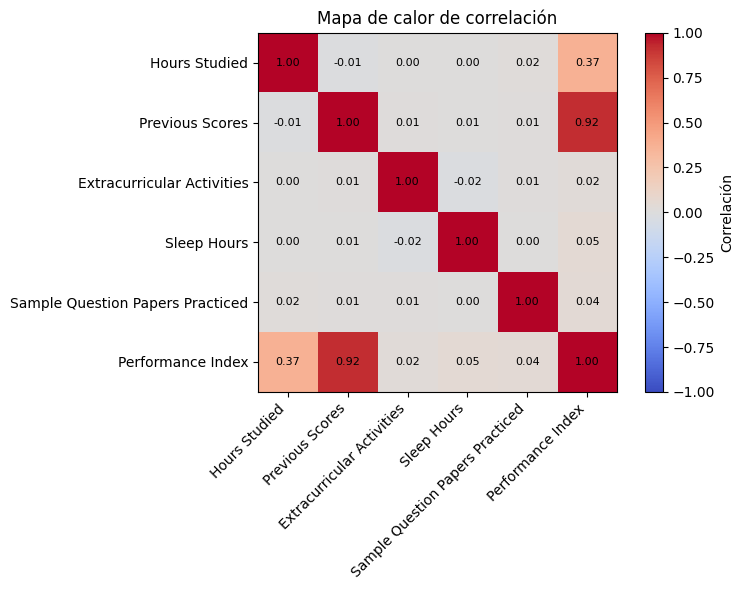


Outliers detectados (z > 3) en alguna variable numérica: 0
Empty DataFrame
Columns: [Hours Studied, Previous Scores, Extracurricular Activities, Sleep Hours, Sample Question Papers Practiced, Performance Index]
Index: []

Interpretación: revisar variables con correlación alta con el target y considerar si los outliers son valores reales o errores de captura.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv('Student_Performance.csv')

print("Filas, columnas:", df.shape)
print("\nColumnas y tipos:")
print(df.dtypes)

print("\nDescribe (numéricas):")
print(df.describe())

print("\nDescribe (todas):")
print(df.describe(include='all'))

# Codificar variable categórica (si existe)
if 'Extracurricular Activities' in df.columns:
    df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

# Variables numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nVariables numéricas:", num_cols)

# Histogramas de variables numéricas
plt.figure(figsize=(12, 8))
for i, c in enumerate(num_cols, 1):
    plt.subplot(2, int(np.ceil(len(num_cols) / 2)), i)
    plt.hist(df[c].dropna(), bins=25, color='tab:blue', edgecolor='black', alpha=0.7)
    plt.title(f"Histograma de {c}")
    plt.xlabel(c)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Boxplots de variables numéricas
plt.figure(figsize=(12, 8))
for i, c in enumerate(num_cols, 1):
    plt.subplot(2, int(np.ceil(len(num_cols) / 2)), i)
    plt.boxplot(df[c].dropna(), vert=False)
    plt.title(f"Boxplot de {c}")
    plt.xlabel(c)
plt.tight_layout()
plt.show()

# Diagramas de dispersión con el target
target = 'Performance Index'
if target in num_cols:
    features = [c for c in num_cols if c != target]
    plt.figure(figsize=(12, 8))
    for i, c in enumerate(features, 1):
        plt.subplot(2, int(np.ceil(len(features) / 2)), i)
        plt.scatter(df[c], df[target], alpha=0.4, s=12)
        plt.title(f"{c} vs {target}")
        plt.xlabel(c)
        plt.ylabel(target)
    plt.tight_layout()
    plt.show()

# Matriz de correlación y mapa de calor con matplotlib
corr = df[num_cols].corr()
print("\nMatriz de correlación numérica:")
print(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlación')
xticks = np.arange(len(num_cols))
plt.xticks(ticks=xticks, labels=num_cols, rotation=45, ha='right')
plt.yticks(ticks=xticks, labels=num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)
plt.title('Mapa de calor de correlación')
plt.tight_layout()
plt.show()

# Detección de outliers con z-score
from scipy import stats
z = np.abs(stats.zscore(df[num_cols], nan_policy='omit'))
outlier_mask = (z > 3).any(axis=1)
outliers = df[outlier_mask]
print(f"\nOutliers detectados (z > 3) en alguna variable numérica: {len(outliers)}")
print(outliers.head(10))

# Interpretación placeholder
print("\nInterpretación: revisar variables con correlación alta con el target y considerar si los outliers son valores reales o errores de captura.")